In [144]:
import sys
from pathlib import Path

# The scripts live one level up, in Analysis/. Make them importable from this notebook.
ANALYSIS = Path.cwd().parent
if str(ANALYSIS) not in sys.path:
    sys.path.insert(0, str(ANALYSIS))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Random, Densification, Dispersion, Flocking
RECORDINGS = ANALYSIS.parent / "Assets/SimulationRecordings/Combinations/Random"
print("recordings:", RECORDINGS)
print("exists:", RECORDINGS.is_dir())

recordings: /Users/cyrusjackson/Documents/Dev/Repos/SwarmRoboticsPerception/Assets/SimulationRecordings/Combinations/Random
exists: True


In [145]:
import plot_grid as pg

runs = pg.load_runs(RECORDINGS)
rows, cols, hue, levels = pg.choose_axes(runs, None, None, None)

print(f"{len(runs)} runs")
print(f"   rows {pg.SHORT[rows]:11s} {levels[rows]}")
print(f"   cols {pg.SHORT[cols]:11s} {levels[cols]}")
print(f"   line {pg.SHORT[hue]:11s} {levels[hue]}")

TITLE = f"{runs[0]['header'].get('swarmType')}  ·  {len(runs)} runs  ·  {runs[0]['header'].get('agentCount')} agents"

6 runs
   rows perception  [0.15, 3.15, 42.15]
   cols max speed   [1.5, 4.0]
   line random      [60.0]


In [146]:
table = pd.DataFrame([{
    "random": r["randomMovement"],
    "perception": r["perceptionRadius"],
    "maxSpeed": r["maxSpeed"],
    "duration": round(float(r["times"][-1]), 2),
    "hull_start": round(float(r["areas"][0]), 1),
    "hull_end": round(float(r["areas"][-1]), 1),
    "hull_ratio": round(float(r["areas"][-1] / r["areas"][0]), 2) if r["areas"][0] > 0 else np.nan,
    "peak_contacts": int(r["contacts"].max()),
    "unique_contacts": int(r["unique"][-1]),
    "ended": r["header"].get("endReason"),
    "file": r["path"].stem,
} for r in runs])

table.sort_values(["perception", "random", "maxSpeed"]).reset_index(drop=True)

,random,perception,maxSpeed,duration,hull_start,hull_end,hull_ratio,peak_contacts,unique_contacts,ended,file
0,60.0,0.15,1.5,62.02,283.4,475.1,1.68,4,7,timeout,type_random_randommovement_60.00_perceptionrad...
1,60.0,0.15,4.0,61.70,234.3,804.7,3.43,16,35,timeout,type_random_randommovement_60.00_perceptionrad...
2,60.0,3.15,1.5,61.70,271.1,368.9,1.36,3,4,timeout,type_random_randommovement_60.00_perceptionrad...
3,60.0,3.15,4.0,61.70,234.0,688.1,2.94,14,35,timeout,type_random_randommovement_60.00_perceptionrad...
4,60.0,42.15,1.5,61.70,281.9,451.8,1.60,3,6,timeout,type_random_randommovement_60.00_perceptionrad...
5,60.0,42.15,4.0,61.70,234.3,842.5,3.60,12,38,timeout,type_random_randommovement_60.00_perceptionrad...


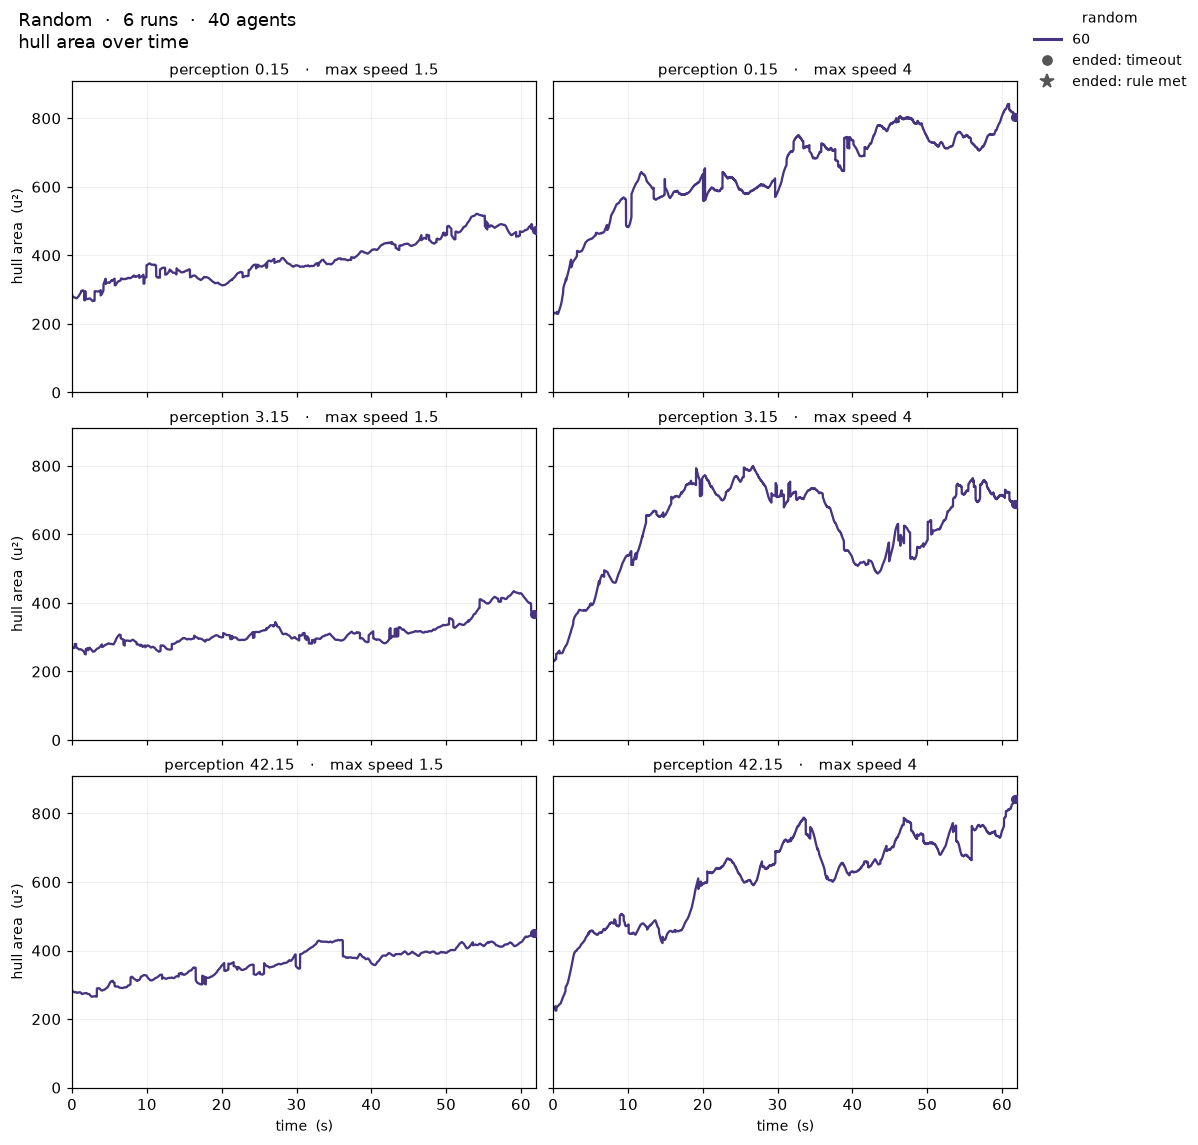

In [147]:
fig = pg.grid_figure(runs, rows, cols, hue, levels, "hull", False, TITLE + "\nhull area over time")
plt.show()

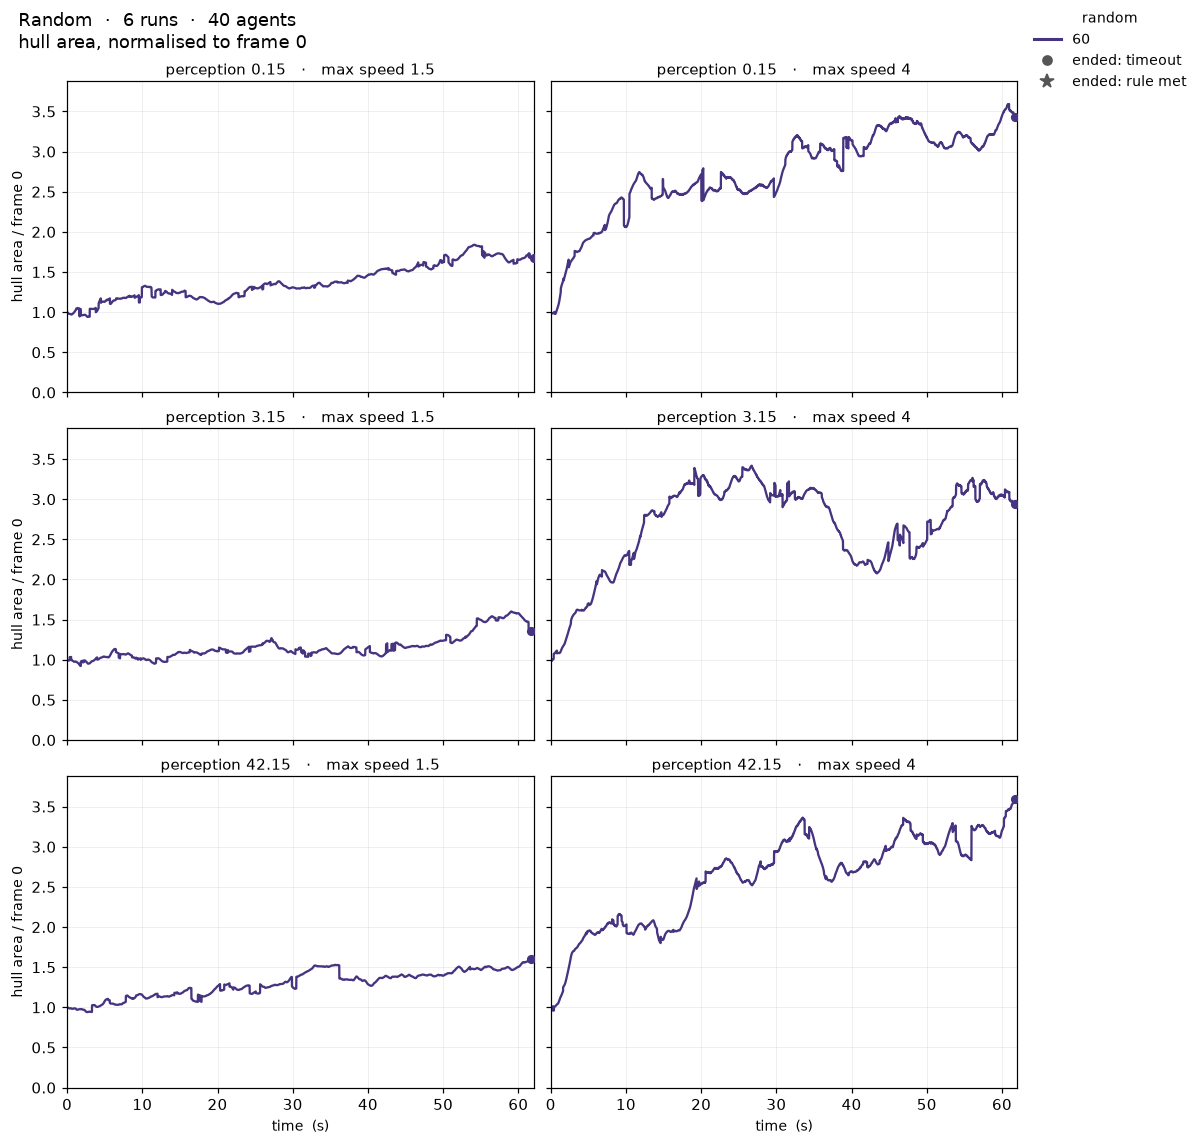

In [148]:
fig = pg.grid_figure(runs, rows, cols, hue, levels, "hull", True,
                     TITLE + "\nhull area, normalised to frame 0")
plt.show()

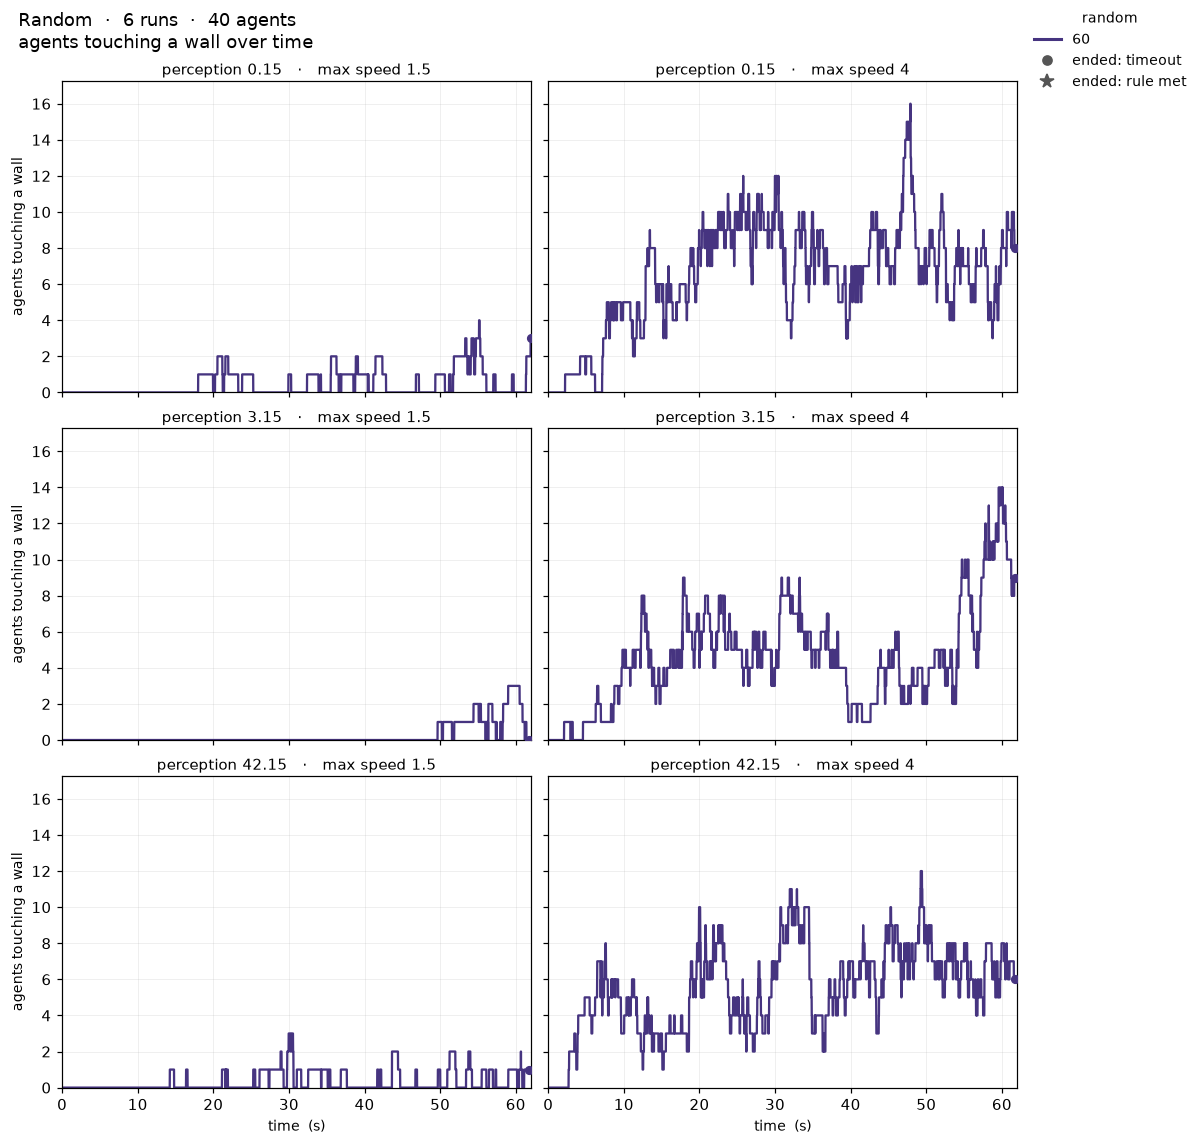

In [149]:
fig = pg.grid_figure(runs, rows, cols, hue, levels, "contacts", False,
                     TITLE + "\nagents touching a wall over time")
plt.show()

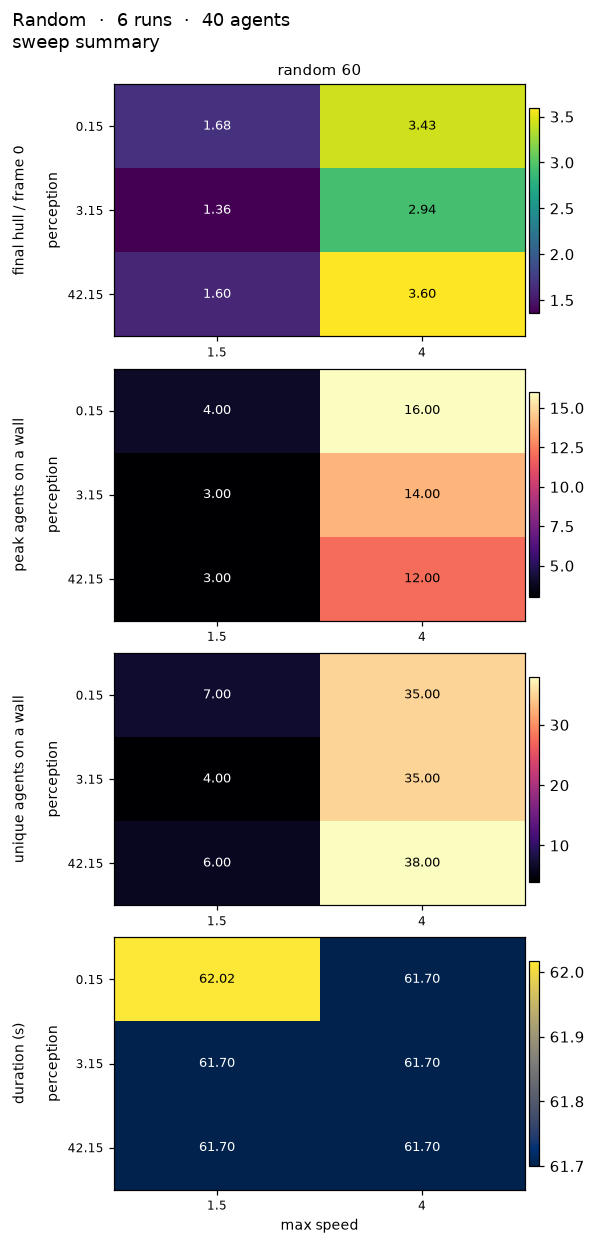

In [150]:
fig = pg.summary_figure(runs, rows, cols, hue, levels, TITLE + "\nsweep summary")
plt.show()

rows perception, cols random, line max speed


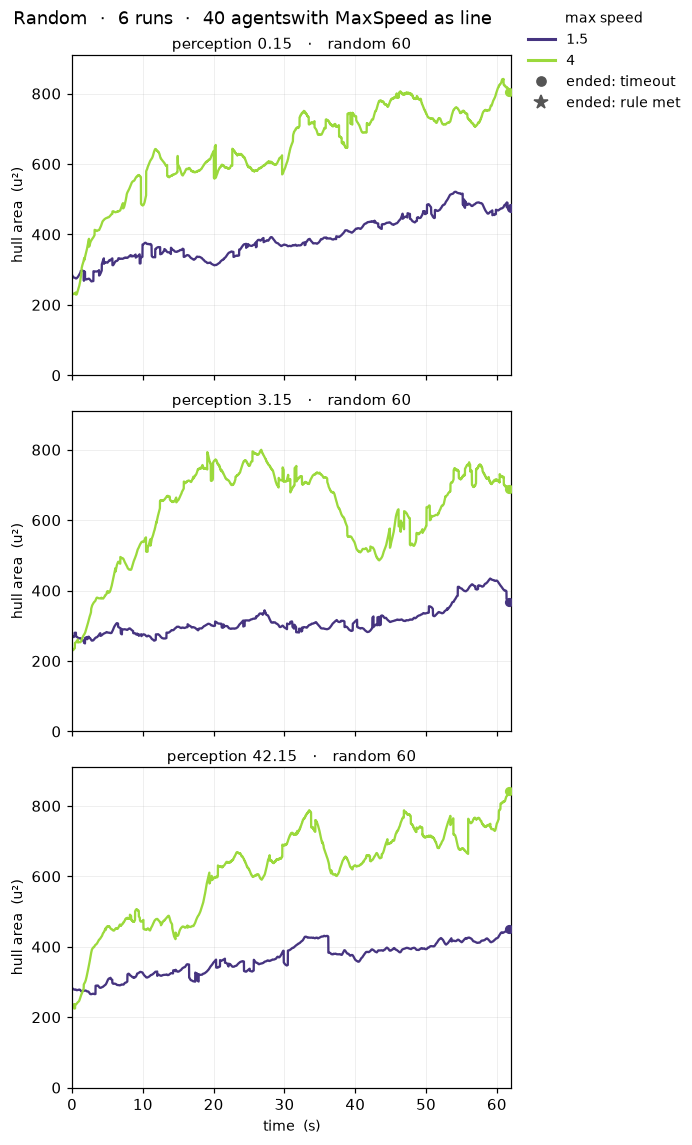

In [151]:
r2, c2, h2, lv2 = pg.choose_axes(runs, rows="perceptionRadius", cols="randomMovement",
                                 hue="maxSpeed")
print(f"rows {pg.SHORT[r2]}, cols {pg.SHORT[c2]}, line {pg.SHORT[h2]}")

fig = pg.grid_figure(runs, r2, c2, h2, lv2, "hull", False, TITLE + "with MaxSpeed as line")
plt.show()

/var/folders/gc/vkzjtbpd4jv2zjf0_x172kk80000gn/T/ipykernel_40699/235382121.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.grid(alpha=0.25); ax.legend()


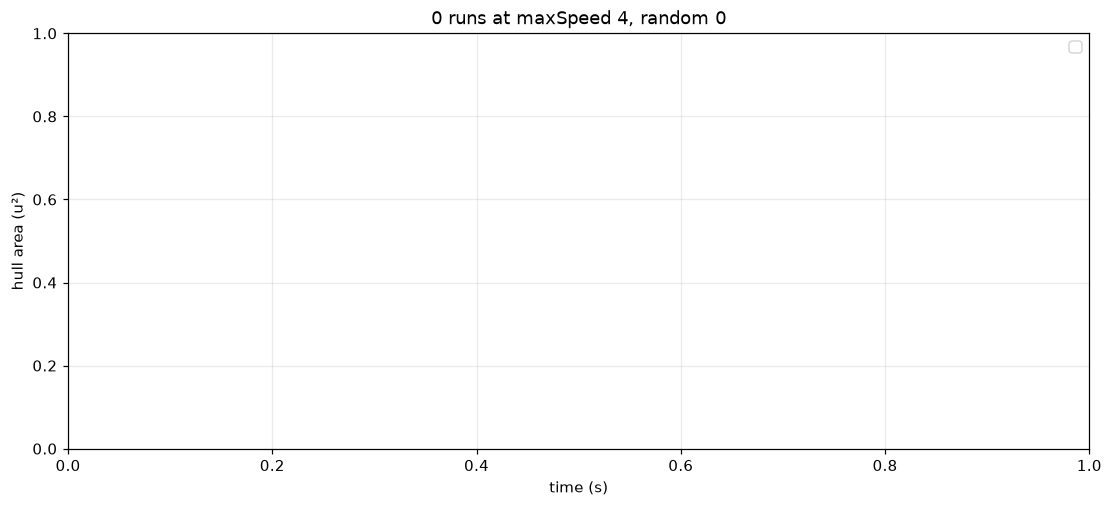

In [152]:
subset = [r for r in runs if r["maxSpeed"] == 4.0 and r["randomMovement"] == 0.0]

fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
for r in sorted(subset, key=lambda r: r["perceptionRadius"]):
    ax.plot(r["times"], r["areas"], linewidth=1.8, label=f"perception {r['perceptionRadius']:g}")

ax.set_xlabel("time (s)"); ax.set_ylabel("hull area (u²)")
ax.grid(alpha=0.25); ax.legend()
ax.set_title(f"{len(subset)} runs at maxSpeed 4, random 0")
plt.show()

In [153]:
out_dir = RECORDINGS / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
stem = (runs[0]["header"].get("swarmType") or "runs").lower()

for metric, name in (("hull", "hull_grid"), ("contacts", "contacts_grid")):
    fig = pg.grid_figure(runs, rows, cols, hue, levels, metric, False, TITLE)
    fig.savefig(out_dir / f"{stem}_{name}.png", dpi=140)
    plt.close(fig)

fig = pg.summary_figure(runs, rows, cols, hue, levels, TITLE)
fig.savefig(out_dir / f"{stem}_summary.png", dpi=140)
plt.close(fig)

print("written to", out_dir)

written to /Users/cyrusjackson/Documents/Dev/Repos/SwarmRoboticsPerception/Assets/SimulationRecordings/Combinations/Random/figures
